Running AQFT Simulation for 8 Qubits...
Simulation Complete. Generating Graphs...


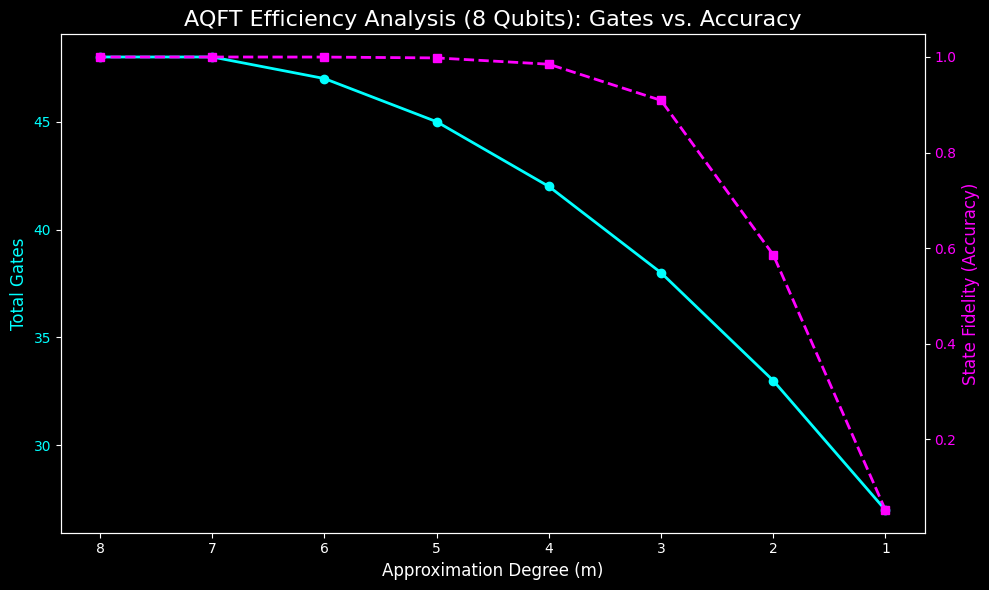

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, state_fidelity

# --- 1. THE CORE ALGORITHM ---
def build_aqft(n, m=None):
    qc = QuantumCircuit(n)
    
    # THE FIX: Flip all qubits to |1> so the phase gates actually trigger
    qc.x(range(n))
    qc.barrier() # Visual separator
    
    for j in range(n):
        qc.h(j)
        for k in range(j + 1, n):
            if m is not None and (k - j) > m:
                continue 
            angle = 2 * np.pi / (2**(k - j + 1))
            qc.cp(angle, k, j)
    for i in range(n // 2):
        qc.swap(i, n - i - 1)
    return qc

# --- 2. THE EXPERIMENT SETUP ---
n_qubits = 8
m_values = list(range(1, n_qubits + 1)) # From m=1 (extreme approx) to m=8 (standard)
gate_counts = []
fidelities = []

print(f"Running AQFT Simulation for {n_qubits} Qubits...")

# Ground Truth (Standard QFT)
qft_standard = build_aqft(n_qubits, m=None)
state_standard = Statevector.from_instruction(qft_standard)

# Run the sweep
for m in m_values:
    qft_approx = build_aqft(n_qubits, m=m)
    state_approx = Statevector.from_instruction(qft_approx)
    
    gate_counts.append(qft_approx.size())
    fidelities.append(state_fidelity(state_standard, state_approx))

print("Simulation Complete. Generating Graphs...")

# --- 3. DATA VISUALIZATION ---
plt.style.use('dark_background') # Looks much better on hackathon slides
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot 1: Gate Count (The Performance Win)
color = 'cyan'
ax1.set_xlabel('Approximation Degree (m)', fontsize=12)
ax1.set_ylabel('Total Gates', color=color, fontsize=12)
ax1.plot(m_values, gate_counts, marker='o', color=color, linewidth=2, label="Gate Count")
ax1.tick_params(axis='y', labelcolor=color)
ax1.invert_xaxis() # Read left to right: Standard -> Extreme Approximation

# Plot 2: Fidelity (The Accuracy Cost)
ax2 = ax1.twinx()  
color = 'magenta'
ax2.set_ylabel('State Fidelity (Accuracy)', color=color, fontsize=12)  
ax2.plot(m_values, fidelities, marker='s', color=color, linewidth=2, linestyle='--', label="Fidelity")
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f'AQFT Efficiency Analysis ({n_qubits} Qubits): Gates vs. Accuracy', fontsize=16)
fig.tight_layout()  

plt.savefig('aqft_results_graph.png', dpi=300)
plt.show()